In [3]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_excel('/content/online_retail_II.xlsx')

df = df.drop_duplicates(subset=[
    'Invoice', 'StockCode', 'InvoiceDate'
])

# quick look
df.head()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (512129, 8)


In [6]:
print(df.shape)
print(df.columns)
df.info()
df.describe()

(512129, 8)
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 512129 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      512129 non-null  object        
 1   StockCode    512129 non-null  object        
 2   Description  509201 non-null  object        
 3   Quantity     512129 non-null  int64         
 4   InvoiceDate  512129 non-null  datetime64[ns]
 5   Price        512129 non-null  float64       
 6   Customer ID  404749 non-null  float64       
 7   Country      512129 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 35.2+ MB


,Quantity,InvoiceDate,Price,Customer ID
count,512129.000000,512129,512129.000000,404749.000000
mean,10.488029,2010-06-28 00:06:38.993222144,4.739626,15346.605452
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-19 16:43:00,1.250000,13975.000000
50%,3.000000,2010-07-05 13:04:00,2.100000,15306.000000
75%,10.000000,2010-10-15 09:31:00,4.210000,16795.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.717207,NaN,148.008936,1682.511174


In [7]:
df = df.dropna()

In [8]:
df = df[df['Quantity'] > 0]

In [9]:
df = df[df['Price'] > 0]

In [10]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [11]:
df['day_of_week'] = df['InvoiceDate'].dt.dayofweek
df['month'] = df['InvoiceDate'].dt.month
df['date'] = df['InvoiceDate'].dt.floor('D')

In [12]:
demand_df = df.groupby(['StockCode', 'date']).agg({
    'Quantity': 'sum',
    'Price': 'mean',
    'day_of_week': 'first',
    'month': 'first'
}).reset_index()

In [13]:
demand_df = demand_df.rename(columns={'Quantity': 'demand'})

In [15]:
# cap extreme demand values
demand_df['demand'] = np.clip(
    demand_df['demand'],
    0,
    demand_df['demand'].quantile(0.99)
)
demand_df.head()

,StockCode,date,demand,Price,day_of_week,month
0,10002,2009-12-01,12,0.85,1,12
1,10002,2009-12-03,6,0.85,3,12
2,10002,2009-12-04,73,0.85,4,12
3,10002,2009-12-06,49,0.85,6,12
4,10002,2009-12-07,2,0.85,0,12


BOX plot

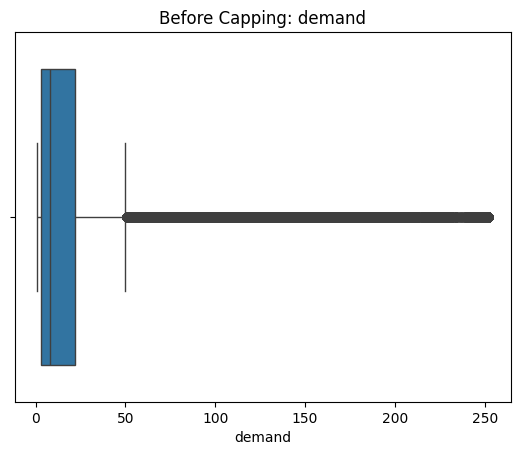

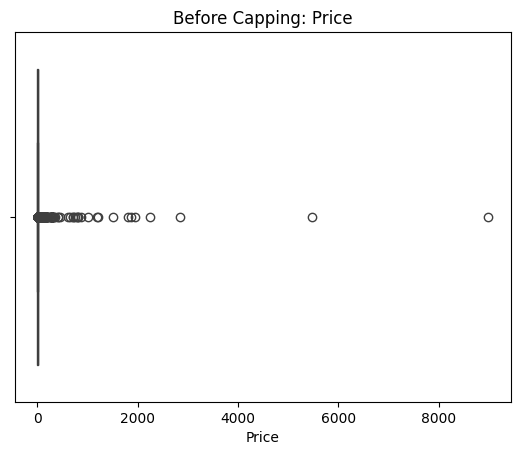

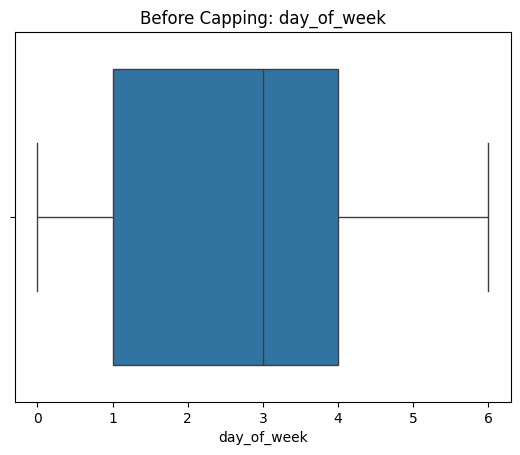

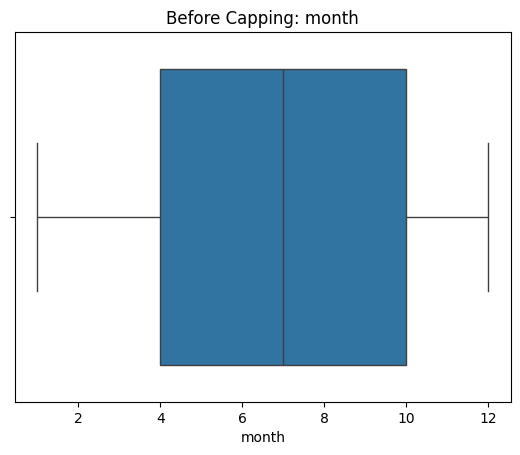

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_cols = demand_df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure()
    sns.boxplot(x=demand_df[col])
    plt.title(f'Before Capping: {col}')
    plt.show()

In [18]:
def cap_outliers(df, col, k=3):
    mean = df[col].mean()
    std = df[col].std()

    lower = mean - k * std
    upper = mean + k * std

    df[col] = np.where(df[col] < lower, lower,
                       np.where(df[col] > upper, upper, df[col]))
    return df

cols_to_cap = ['demand', 'Price']

for col in cols_to_cap:
    demand_df = cap_outliers(demand_df, col, k=3)

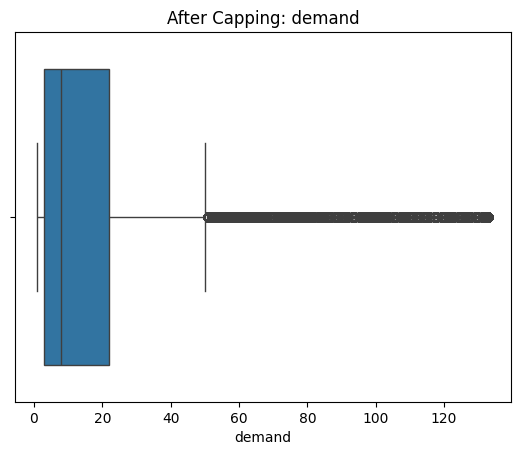

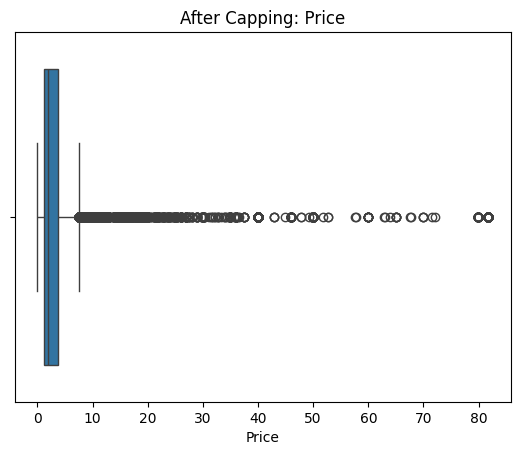

In [19]:
for col in cols_to_cap:
    plt.figure()
    sns.boxplot(x=demand_df[col])
    plt.title(f'After Capping: {col}')
    plt.show()

In [20]:
print(demand_df.isnull().sum())
print(demand_df.shape)

StockCode      0
date           0
demand         0
Price          0
day_of_week    0
month          0
dtype: int64
(223824, 6)


In [21]:
demand_df.to_csv('clean_demand_data.csv', index=False)

In [22]:
from google.colab import files
files.download('clean_demand_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

*Checking Dataset Quality*

In [23]:
print(demand_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223824 entries, 0 to 223823
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   StockCode    223824 non-null  object        
 1   date         223824 non-null  datetime64[ns]
 2   demand       223824 non-null  float64       
 3   Price        223824 non-null  float64       
 4   day_of_week  223824 non-null  int32         
 5   month        223824 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(2), object(1)
memory usage: 8.5+ MB
None


In [24]:
demand_df.describe()

,date,demand,Price,day_of_week,month
count,223824,223824.000000,223824.000000,223824.000000,223824.000000
mean,2010-06-21 20:25:37.508041728,18.393301,3.056675,2.667681,7.095195
min,2009-12-01 00:00:00,1.000000,0.001000,0.000000,1.000000
25%,2010-03-18 00:00:00,3.000000,1.250000,1.000000,4.000000
50%,2010-06-27 00:00:00,8.000000,1.950000,3.000000,7.000000
75%,2010-10-04 00:00:00,22.000000,3.750000,4.000000,10.000000
max,2010-12-09 00:00:00,132.942713,81.756946,6.000000,12.000000
std,NaN,27.759341,4.071437,1.965880,3.491175


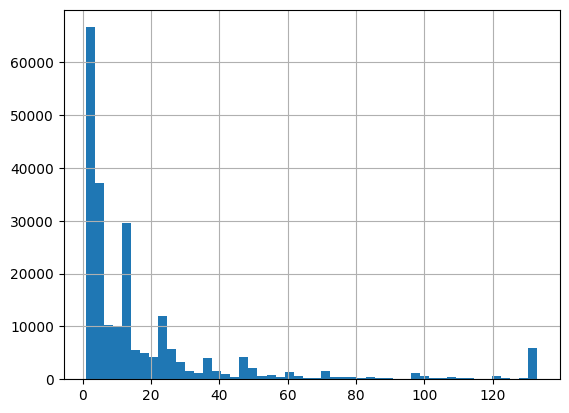

In [25]:
import matplotlib.pyplot as plt

demand_df['demand'].hist(bins=50)
plt.show()

In [26]:
print("Unique products:", demand_df['StockCode'].nunique())

Unique products: 4017


In [27]:
demand_df.groupby('StockCode')['Price'].nunique().describe()

,Price
count,4017.000000
mean,3.253174
std,4.110207
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,91.000000


In [28]:
demand_df[['Price', 'demand']].corr()

,Price,demand
Price,1.000000,-0.189781
demand,-0.189781,1.000000


In [29]:
demand_df.sample(5)

,StockCode,date,demand,Price,day_of_week,month
135473,22548,2010-05-13,24.000000,1.250000,3,5
7120,20719,2010-06-14,30.000000,0.850000,0,6
96559,22144,2010-11-11,132.942713,2.077273,3,11
73187,21877,2010-01-19,25.000000,1.250000,1,1
223324,C2,2010-10-05,1.000000,50.000000,1,10
